In [ ]:
# MIT Lab 2 | Image Classification
# PyTorch then TensorFlow in one notebook
# Dataset: CIFAR-10 (real color images) instead of MNIST handwritten digits

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


100%|██████████| 170M/170M [00:02<00:00, 59.3MB/s]


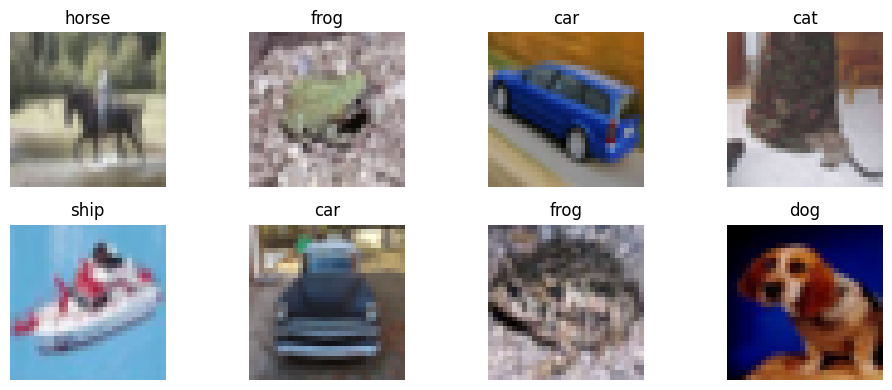

Train size: 50000
Test size: 10000
Image shape: torch.Size([3, 32, 32])


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

# peek at a few samples
images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    img = images[i] * 0.5 + 0.5  # unnormalize
    plt.imshow(img.permute(1, 2, 0))
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")
print(f"Image shape: {images[0].shape}")

In [ ]:
class FCModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3 * 32 * 32, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

fc_model = FCModel().to(device)
print(fc_model)

# sanity check
test_input = torch.randn(4, 3, 32, 32).to(device)
print(f"Output shape: {fc_model(test_input).shape}")

FCModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Output shape: torch.Size([4, 10])


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(fc_model.parameters(), lr=0.01)

EPOCHS = 5
for epoch in range(EPOCHS):
    fc_model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = fc_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    acc = correct / total
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.4f}")

Epoch 1/5 | Loss: 1.8879 | Acc: 0.3418
Epoch 2/5 | Loss: 1.6718 | Acc: 0.4166
Epoch 3/5 | Loss: 1.5916 | Acc: 0.4452
Epoch 4/5 | Loss: 1.5376 | Acc: 0.4636
Epoch 5/5 | Loss: 1.4959 | Acc: 0.4806


In [ ]:
fc_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = fc_model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

print(f"FC Model Test Accuracy: {correct/total:.4f}")

FC Model Test Accuracy: 0.4789


In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

cnn_model = CNN().to(device)
print(cnn_model)

test_input = torch.randn(4, 3, 32, 32).to(device)
print(f"Output shape: {cnn_model(test_input).shape}")

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Output shape: torch.Size([4, 10])


In [ ]:
optimizer = optim.SGD(cnn_model.parameters(), lr=0.01)

EPOCHS = 5
for epoch in range(EPOCHS):
    cnn_model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    acc = correct / total
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Acc: {acc:.4f}")

cnn_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = cnn_model(images)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
print(f"\nCNN Test Accuracy: {correct/total:.4f}")
print(f"FC Test Accuracy:  0.4789")
print(f"Improvement: {(correct/total - 0.4789)*100:.1f}%")

Epoch 1/5 | Loss: 2.0378 | Acc: 0.2792
Epoch 2/5 | Loss: 1.6714 | Acc: 0.4068
Epoch 3/5 | Loss: 1.4745 | Acc: 0.4729
Epoch 4/5 | Loss: 1.3556 | Acc: 0.5174
Epoch 5/5 | Loss: 1.2707 | Acc: 0.5485

CNN Test Accuracy: 0.5387
FC Test Accuracy:  0.4789
Improvement: 6.0%


In [ ]:
# ============================================================
# PyTorch section complete.
# Rebuilding same FC + CNN in TensorFlow/Keras on CIFAR-10
# ============================================================

import tensorflow as tf

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"TF version: {tf.__version__}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
TF version: 2.19.0


In [ ]:
tf_fc_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32, 32, 3)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

tf_fc_model.compile(optimizer='sgd',
                    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                    metrics=['accuracy'])

tf_fc_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_fc = tf_fc_model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=1)

test_loss, test_acc = tf_fc_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTF FC Test Accuracy: {test_acc:.4f}")

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2617 - loss: 2.0359
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3661 - loss: 1.7935
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3987 - loss: 1.7154
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4176 - loss: 1.6706
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4329 - loss: 1.6236

TF FC Test Accuracy: 0.3765


In [ ]:
tf_cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

tf_cnn_model.compile(optimizer='sgd',
                     loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                     metrics=['accuracy'])

history_cnn = tf_cnn_model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=1)

test_loss, test_acc = tf_cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTF CNN Test Accuracy: {test_acc:.4f}")
print(f"TF FC  Test Accuracy: 0.3765")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2041 - loss: 2.1714
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3615 - loss: 1.8154
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4354 - loss: 1.6032
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4877 - loss: 1.4460
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5159 - loss: 1.3583

TF CNN Test Accuracy: 0.5013
TF FC  Test Accuracy: 0.3765


In [ ]:
print("=" * 45)
print("CIFAR-10 Classification Results")
print("=" * 45)
print(f"PyTorch  FC  Test Accuracy:  0.4789")
print(f"PyTorch  CNN Test Accuracy:  0.5387")
print(f"TF       FC  Test Accuracy:  0.3765")
print(f"TF       CNN Test Accuracy:  0.5013")
print("=" * 45)
print("CNN outperforms FC in both frameworks.")
print("Spatial feature extraction via convolutions")
print("makes the difference on image data.")

CIFAR-10 Classification Results
PyTorch  FC  Test Accuracy:  0.4789
PyTorch  CNN Test Accuracy:  0.5387
TF       FC  Test Accuracy:  0.3765
TF       CNN Test Accuracy:  0.5013
CNN outperforms FC in both frameworks.
Spatial feature extraction via convolutions
makes the difference on image data.


# Lab 2 Recap — Image Classification with FC & CNN

## What We Built
Two classifiers — a fully connected network and a CNN — trained on CIFAR-10
(real color images of cats, dogs, cars etc.) instead of the original MNIST digits.

## The Process
1. Loaded CIFAR-10 — 50,000 training images across 10 classes
2. Built a simple FC network: flatten image → dense layers → classify
3. Built a CNN: conv layers extract spatial features → pooling → dense → classify
4. Trained and evaluated both in PyTorch, then rebuilt both in TensorFlow
5. Compared results across frameworks and architectures

## Key Concepts Practiced
- Flattening vs preserving spatial structure in images
- Convolutional layers, max pooling, and why they work for vision tasks
- Same architecture built two ways: PyTorch (manual loop) vs TF/Keras (fit API)
- Evaluating and comparing models on a held-out test set

## Results
| Framework  | Model | Test Accuracy |
|------------|-------|---------------|
| PyTorch    | FC    | 47.89%        |
| PyTorch    | CNN   | 53.87%        |
| TensorFlow | FC    | 37.65%        |
| TensorFlow | CNN   | 50.13%        |

## Takeaway
CNNs consistently outperform fully connected networks on image data because
they learn spatial patterns like edges and shapes rather than treating every
pixel independently. CIFAR-10 is harder than MNIST — color, texture, and
background variation make it a more realistic benchmark.